# Regressão 01 - tarefa 02 - transformações em X e Y

### 1. Melhorando o ajuste no percentual de gorjetas

a. Vamos partir do modelo feito na última tarefa, o que relaciona ```tip_pct``` e ```net_bill```. Carregue a base, os pacotes e reproduza este modelo aqui.

                            OLS Regression Results                            
Dep. Variable:           perc_gorjeta   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     56.10
Date:                Sun, 01 Dec 2024   Prob (F-statistic):           1.31e-12
Time:                        16:15:50   Log-Likelihood:                 331.48
No. Observations:                 242   AIC:                            -659.0
Df Residuals:                     240   BIC:                            -652.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.2538      0.009     27.252

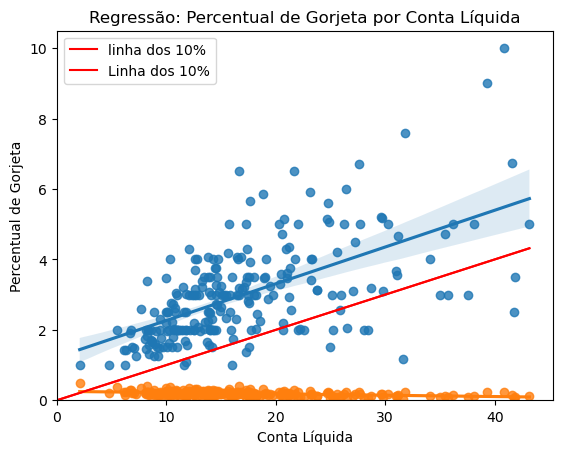

(0.10889974845461381, 0.3325407312323707)

In [24]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.formula.api as smf

tips = sns.load_dataset('tips')
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips['tip_pct'] = tips['tip'] / tips['net_bill']
tips = tips[tips['tip_pct'] < .5]
tips.drop(['total_bill', 'sex', 'smoker', 'day', 'time', 'size'], axis=1, inplace=True)
tips.head()

# Gráfico de dispersão
sns.regplot(y = 'tip', x = 'net_bill', data = tips[tips['tip_pct']<.5])

# Gerando dados para a linha dos 10%
x = np.linspace(0,tips['net_bill'].max(),100)
y = .1*x

# Plotando a linha dos 10%
plt.plot(x, y, '-r', label='linha dos 10%')

# Opções estéticas para explicitar o (0,0) no gráfico
plt.xlim(left = 0)
plt.ylim(bottom = 0)

reg = smf.ols('tip ~ net_bill', data = tips).fit()
reg.summary()

dados_novos = tips[0:5]
dados_novos

# Predição de dados novos
reg.predict(dados_novos)

# Onde o Python guarda os parâmetros?
reg.params

# Carregar o dataset
gorjetas = sns.load_dataset("tips")

# Criar novas colunas
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['perc_gorjeta'] < 0.5]

# Gráfico de dispersão
sns.regplot(y='perc_gorjeta', x='conta_liquida', data=dados_filtrados)

# Ajustar modelo de regressão
modelo = smf.ols('perc_gorjeta ~ conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo.summary())

# Adicionar linha de 10% ao gráfico para comparação
x = np.linspace(0, gorjetas['conta_liquida'].max(), 100)
y = 0.1  # Representa uma gorjeta de 10% fixa em relação ao valor líquido
plt.plot(x, y * x, '-r', label='Linha dos 10%')

# Melhorar estética do gráfico
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel('Conta Líquida')
plt.ylabel('Percentual de Gorjeta')
plt.title('Regressão: Percentual de Gorjeta por Conta Líquida')
plt.legend()

# Exibir o gráfico
plt.show()

# Ajustar o modelo para perc_gorjeta ~ conta_liquida
modelo_perc = smf.ols('perc_gorjeta ~ conta_liquida', data=gorjetas).fit()

# Obter os valores preditos para perc_gorjeta (tip_pct)
gorjetas['pred_perc_gorjeta'] = modelo_perc.fittedvalues

# Calcular os valores preditos para gorjeta (tip) como perc_gorjeta * conta_liquida
gorjetas['pred_gorjeta'] = gorjetas['pred_perc_gorjeta'] * gorjetas['conta_liquida']

# Calcular o R² do modelo para gorjeta (tip) usando os valores reais e preditos
from sklearn.metrics import r2_score
r2_gorjeta_ajustado = r2_score(gorjetas['tip'], gorjetas['pred_gorjeta'])

# Ajustar o modelo original tip ~ conta_liquida para obter o R² original
modelo_original = smf.ols('tip ~ conta_liquida', data=gorjetas).fit()
r2_gorjeta_original = modelo_original.rsquared

# Exibir os R² ajustado e original
r2_gorjeta_ajustado, r2_gorjeta_original


### 2. ajuste o modelo de ```tip_pct``` em função do logaritmo de ```net_bill```.

In [26]:
# Criar novas colunas
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Criar coluna logarítmica
gorjetas['log_conta_liquida'] = np.log(gorjetas['conta_liquida'])

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['perc_gorjeta'] < 0.5]

# Ajustar modelo de regressão com logaritmo de conta líquida
modelo_log = smf.ols('perc_gorjeta ~ log_conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:           perc_gorjeta   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     68.11
Date:                Sun, 01 Dec 2024   Prob (F-statistic):           1.03e-14
Time:                        16:15:53   Log-Likelihood:                 336.29
No. Observations:                 242   AIC:                            -668.6
Df Residuals:                     240   BIC:                            -661.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.3818      0.02

###  3. ajuste o modelo de ```tip_pct``` em função de um polinômio de segundo grau em ```net_bill```.

In [28]:
# Criar novas colunas
gorjetas['perc_gorjeta'] = gorjetas['tip'] / (gorjetas['total_bill'] - gorjetas['tip'])
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['perc_gorjeta'] < 0.5]

# Ajustar modelo de regressão com polinômio de segundo grau
modelo_polinomio = smf.ols('perc_gorjeta ~ conta_liquida + I(conta_liquida ** 2)', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_polinomio.summary())

                            OLS Regression Results                            
Dep. Variable:           perc_gorjeta   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     30.98
Date:                Sun, 01 Dec 2024   Prob (F-statistic):           1.09e-12
Time:                        16:15:56   Log-Likelihood:                 333.96
No. Observations:                 242   AIC:                            -661.9
Df Residuals:                     239   BIC:                            -651.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.29

###  4. ajuste um modelo no log do ```tip_pct``` em função de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```

In [30]:
# Criar novas colunas
gorjetas['tip_pct'] = gorjetas['tip'] / gorjetas['total_bill']
gorjetas['conta_liquida'] = gorjetas['total_bill'] - gorjetas['tip']

# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['tip_pct'] < 0.5]

# Ajustar modelo de regressão no log de tip_pct
modelo_log = smf.ols('np.log(tip_pct) ~ conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_log.summary())

# Calcular R² para tip_pct
r_squared = modelo_log.rsquared
print(f'R² para log(tip_pct): {r_squared}')

                            OLS Regression Results                            
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     73.45
Date:                Sun, 01 Dec 2024   Prob (F-statistic):           1.25e-15
Time:                        16:15:58   Log-Likelihood:                -47.357
No. Observations:                 243   AIC:                             98.71
Df Residuals:                     241   BIC:                             105.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.5513      0.044    -35.047

###  5. ajuste um modelo no log do ```tip_pct``` em função do log de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```.

In [32]:
# Filtrar dados para evitar outliers (porcentagem de gorjeta menor que 50%)
dados_filtrados = gorjetas[gorjetas['tip_pct'] < 0.5]

# Criar a coluna logarítmica da conta líquida
dados_filtrados['log_conta_liquida'] = np.log(dados_filtrados['conta_liquida'])

# Ajustar modelo de regressão no log de tip_pct em função do log de conta líquida
modelo_log = smf.ols('np.log(tip_pct) ~ log_conta_liquida', data=dados_filtrados).fit()

# Resumo do modelo
print(modelo_log.summary())

# Calcular R² para tip_pct
r_squared = modelo_log.rsquared
print(f'R² para log(tip_pct): {r_squared}')

                            OLS Regression Results                            
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     76.56
Date:                Sun, 01 Dec 2024   Prob (F-statistic):           3.78e-16
Time:                        16:16:00   Log-Likelihood:                -46.163
No. Observations:                 243   AIC:                             96.33
Df Residuals:                     241   BIC:                             103.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.9219      0.11

C:\Users\fabio\AppData\Local\Temp\ipykernel_9312\960555350.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_filtrados['log_conta_liquida'] = np.log(dados_filtrados['conta_liquida'])


###  6. qual modelo resultou no melhor ajuste?

O R² do modelo 3 foi o maior, isso sugere que a relação entre tip_pct e net_bill é mais bem capturada pela transformação logarítmica.